# Preprocessing dan Ekstraksi Fitur Polutan Udara (CO, CH4, NO2, SO2)

Halaman ini mendokumentasikan seluruh tahapan pemrosesan data deret waktu (*time series*) untuk empat polutan utama di Kabupaten Lamongan:
1. **Karbon Monoksida (CO)**
2. **Metana (CH4)**
3. **Nitrogen Dioksida (NO2)**
4. **Sulfur Dioksida (SO2)**

Tahapan pengolahan data meliputi:
- **Deteksi & Imputasi Missing Value** menggunakan metode *Linear Interpolation*.
- **Deteksi Outlier** menggunakan metode *Interquartile Range (IQR)* beserta visualisasinya.
- **Penanganan Outlier & Pembersihan Data**.
- **Ekstraksi Fitur Time Series (68 Fitur TSFEL)** yang mencakup domain *Statistical*, *Temporal*, dan *Spectral*.

---

## 1. Preprocessing: Deteksi & Imputasi Missing Value (Interpolasi Linear)

*Missing value* adalah kondisi saat terdapat data yang tidak terekam pada periode observasi tertentu akibat kendala tutupan awan atau gangguan sensor satelit Sentinel-5P. 

Metode **Interpolasi Linear** memperkirakan nilai yang hilang berdasarkan tren linier antara titik data sebelum dan sesudahnya:
$$y = y_1 + \frac{(x - x_1)(y_2 - y_1)}{x_2 - x_1}$$

Untuk nilai kosong di bagian awal atau akhir data deret waktu yang tidak memiliki titik batas, diterapkan teknik **Forward Fill (`ffill`)** dan **Backward Fill (`bfill`)**.

In [1]:
import pandas as pd
import numpy as np

# Daftar polutan dan lokasi dataset
pollutants = {
    "CO": "data/CO_lamongan.csv",
    "CH4": "data/CH4_lamongan.csv",
    "NO2": "data/No2_lamongan.csv",
    "SO2": "data/SO2_lamongan.csv"
}

missing_summary = []
dfs_imputed = {}

for polutan, path in pollutants.items():
    df = pd.read_csv(path)
    df['date'] = pd.to_datetime(df['date'], format='mixed')
    df = df.sort_values('date').reset_index(drop=True)
    df[polutan] = pd.to_numeric(df[polutan], errors='coerce')
    
    total_data = len(df)
    missing_before = df[polutan].isnull().sum()
    pct_missing = (missing_before / total_data) * 100
    
    # Imputasi Missing Value dengan Linear Interpolation, ffill, bfill
    df_clean = df.copy()
    df_clean[polutan] = df_clean[polutan].ffill().bfill().interpolate(method='linear')
    missing_after = df_clean[polutan].isnull().sum()
    
    # Simpan dataset hasil imputasi missing
    save_path = f"data/{polutan}_lamongan_missing.csv"
    df_clean.to_csv(save_path, index=False)
    dfs_imputed[polutan] = df_clean
    
    missing_summary.append({
        "Polutan": polutan,
        "Total Data": total_data,
        "Missing Awal": missing_before,
        "Persentase Missing": f"{pct_missing:.2f}%",
        "Missing Setelah Imputasi": missing_after,
        "Status": "Bersih (0 Missing)"
    })

pd.DataFrame(missing_summary)

,Polutan,Total Data,Missing Awal,Persentase Missing,Missing Setelah Imputasi,Status
0,CO,366,76,20.77%,0,Bersih (0 Missing)
1,CH4,366,351,95.90%,0,Bersih (0 Missing)
2,NO2,364,99,27.20%,0,Bersih (0 Missing)
3,SO2,366,190,51.91%,0,Bersih (0 Missing)


---

## 2. Preprocessing: Deteksi Outlier dengan Interquartile Range (IQR)

*Interquartile Range (IQR)* mengukur penyebaran 50% data bagian tengah antara Kuartil Pertama ($Q_1$) dan Kuartil Ketiga ($Q_3$):
$$\text{IQR} = Q_3 - Q_1$$

Batas ambang deteksi data pencilan (*outlier*):
- **Batas Bawah (*Lower Bound*):**
  $$\text{Batas Bawah} = Q_1 - 1.5 \times \text{IQR}$$
- **Batas Atas (*Upper Bound*):**
  $$\text{Batas Atas} = Q_3 + 1.5 \times \text{IQR}$$

Data dengan nilai $x < \text{Batas Bawah}$ atau $x > \text{Batas Atas}$ dikategorikan sebagai **Outlier**.

In [2]:
iqr_summary = []
outliers_dict = {}

for polutan, df in dfs_imputed.items():
    series = df[polutan]
    
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    
    batas_bawah = q1 - 1.5 * iqr
    batas_atas = q3 + 1.5 * iqr
    
    is_outlier = (series < batas_bawah) | (series > batas_atas)
    outlier_count = is_outlier.sum()
    outliers_dict[polutan] = df[is_outlier]
    
    iqr_summary.append({
        "Polutan": polutan,
        "Q1 (25%)": q1,
        "Q3 (75%)": q3,
        "IQR": iqr,
        "Batas Bawah": batas_bawah,
        "Batas Atas": batas_atas,
        "Jumlah Outlier": outlier_count,
        "Persentase Outlier": f"{(outlier_count / len(df)) * 100:.2f}%"
    })

pd.DataFrame(iqr_summary)

,Polutan,Q1 (25%),Q3 (75%),IQR,Batas Bawah,Batas Atas,Jumlah Outlier,Persentase Outlier
0,CO,0.027136,0.031578,0.004442,0.020473,0.038240,8,2.19%
1,CH4,1853.304443,1891.488878,38.184435,1796.027791,1948.765530,0,0.00%
2,NO2,0.000021,0.000031,0.000010,0.000006,0.000046,8,2.20%
3,SO2,-0.000089,0.000179,0.000268,-0.000490,0.000580,17,4.64%


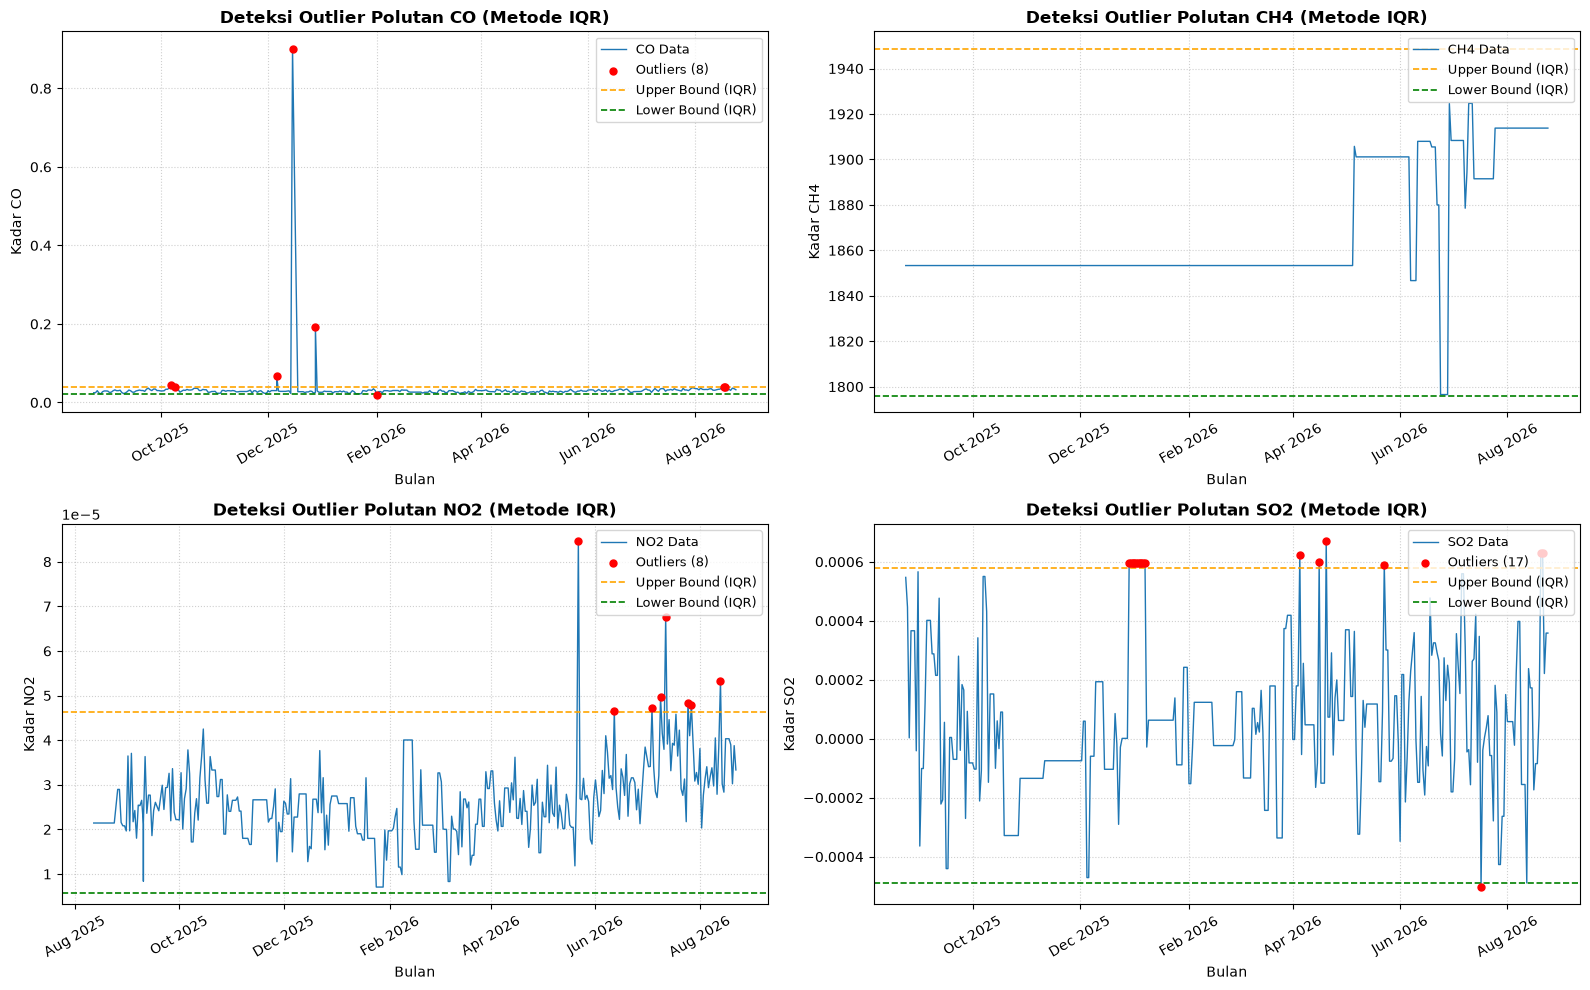

In [3]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, (polutan, df) in enumerate(dfs_imputed.items()):
    ax = axes[idx]
    
    q1 = df[polutan].quantile(0.25)
    q3 = df[polutan].quantile(0.75)
    iqr = q3 - q1
    batas_bawah = q1 - 1.5 * iqr
    batas_atas = q3 + 1.5 * iqr
    
    outliers = df[(df[polutan] < batas_bawah) | (df[polutan] > batas_atas)]
    
    # Plot garis time series
    ax.plot(df['date'], df[polutan], label=f'{polutan} Data', linewidth=1, color='#1f77b4')
    
    # Titik outlier
    if len(outliers) > 0:
        ax.scatter(outliers['date'], outliers[polutan], color='red', s=25, label=f'Outliers ({len(outliers)})', zorder=5)
    
    # Garis ambang batas IQR
    ax.axhline(batas_atas, color='orange', linestyle='--', linewidth=1.2, label='Upper Bound (IQR)')
    ax.axhline(batas_bawah, color='green', linestyle='--', linewidth=1.2, label='Lower Bound (IQR)')
    
    ax.set_title(f'Deteksi Outlier Polutan {polutan} (Metode IQR)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Bulan', fontsize=10)
    ax.set_ylabel(f'Kadar {polutan}', fontsize=10)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.tick_params(axis='x', rotation=30)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

---

## 2.1 Perbandingan Deteksi Outlier Metode Machine Learning & Probabilitas (PyOD)

Selain menerapkan pendekatan statistik konvensional seperti **Interquartile Range (IQR)** untuk mengidentifikasi data pencilan, analisis juga diperluas dengan membandingkan beberapa algoritma deteksi outlier yang tersedia dalam pustaka **PyOD**. Sebanyak **3 metode berbasis Machine Learning dan probabilitas** digunakan dalam pengujian:
- **KNN (*k-Nearest Neighbors*)**: Mengukur jarak suatu data ke k-tetangga terdekat. Jika jaraknya jauh, titik tersebut dianggap outlier.
- **Isolation Forest**: Memisahkan data secara acak menggunakan pohon biner; titik anomali lebih cepat terisolasi.
- **ECOD (*Empirical Cumulative Distribution Functions*)**: Menilai anomali berdasarkan fungsi distribusi kumulatif empiris pada ekor data.

In [4]:
from sklearn.preprocessing import StandardScaler
from pyod.models.knn import KNN
from pyod.models.iforest import IForest
from pyod.models.ecod import ECOD

BULAN_MAP = {
    1: 'Januari', 2: 'Februari', 3: 'Maret', 4: 'April', 5: 'Mei', 6: 'Juni', 
    7: 'Juli', 8: 'Agustus', 9: 'September', 10: 'Oktober', 11: 'November', 12: 'Desember'
}

for polutan, df in dfs_imputed.items():
    df_valid = df.dropna(subset=[polutan]).copy()
    
    # Standarisasi data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_valid[[polutan]].values)
    
    models = {
        'KNN': KNN(n_neighbors=5),
        'Isolation Forest': IForest(random_state=42),
        'ECOD': ECOD()
    }
    
    print("=" * 75)
    print(f"       DETEKSI OUTLIER DINAMIS (PyOD Anomaly Score) — {polutan}")
    print("=" * 75)
    print(f"Total Data Valid: {len(df_valid)} hari\n")
    
    for name, model in models.items():
        # Training model
        model.fit(X_scaled)
        
        # Ambil skor anomali kontinu (semakin tinggi = semakin anomali)
        scores = model.decision_scores_
        
        # Threshold Dinamis: Nilai di luar mean + 2.5 * std
        dynamic_threshold = scores.mean() + (2.5 * scores.std())
        
        is_outlier = scores > dynamic_threshold
        df_valid[f'outlier_{name}'] = is_outlier.astype(int)
        
        outliers_m = df_valid[df_valid[f'outlier_{name}'] == 1]
        persen = (len(outliers_m) / len(df_valid)) * 100
        
        print(f">>> Metode: {name:<18} | Jumlah Outlier: {len(outliers_m)} hari ({persen:.2f}%)")
        if len(outliers_m) > 0:
            for idx, row in outliers_m.iterrows():
                dt = pd.to_datetime(row['date'])
                score_val = scores[df_valid.index.get_loc(idx)]
                print(f"    • {dt.day:>2} {BULAN_MAP[dt.month]:<9} {dt.year} | Nilai: {row[polutan]:.6g} (Skor Anomali: {score_val:.3f})")
        else:
            print("    (Tidak ditemukan data anomali ekstrem)")
        print()

       DETEKSI OUTLIER DINAMIS (PyOD Anomaly Score) — CO
Total Data Valid: 366 hari

>>> Metode: KNN                | Jumlah Outlier: 2 hari (0.55%)
    • 15 Desember  2025 | Nilai: 0.901257 (Skor Anomali: 18.585)
    • 28 Desember  2025 | Nilai: 0.191613 (Skor Anomali: 3.302)



>>> Metode: Isolation Forest   | Jumlah Outlier: 10 hari (2.73%)
    • 28 Agustus   2025 | Nilai: 0.021727 (Skor Anomali: 0.130)
    •  7 Oktober   2025 | Nilai: 0.0434917 (Skor Anomali: 0.248)
    •  9 Oktober   2025 | Nilai: 0.0390352 (Skor Anomali: 0.161)
    •  6 Desember  2025 | Nilai: 0.0673069 (Skor Anomali: 0.338)
    • 15 Desember  2025 | Nilai: 0.901257 (Skor Anomali: 0.439)
    • 28 Desember  2025 | Nilai: 0.191613 (Skor Anomali: 0.397)
    •  1 Februari  2026 | Nilai: 0.0202148 (Skor Anomali: 0.220)
    • 16 Agustus   2026 | Nilai: 0.0382186 (Skor Anomali: 0.113)
    • 17 Agustus   2026 | Nilai: 0.0383145 (Skor Anomali: 0.108)
    • 18 Agustus   2026 | Nilai: 0.0383145 (Skor Anomali: 0.108)



>>> Metode: ECOD               | Jumlah Outlier: 11 hari (3.01%)
    • 28 Agustus   2025 | Nilai: 0.021727 (Skor Anomali: 5.209)
    •  7 Oktober   2025 | Nilai: 0.0434917 (Skor Anomali: 4.516)
    •  9 Oktober   2025 | Nilai: 0.0390352 (Skor Anomali: 4.293)
    •  6 Desember  2025 | Nilai: 0.0673069 (Skor Anomali: 4.804)
    • 15 Desember  2025 | Nilai: 0.901257 (Skor Anomali: 5.903)
    • 28 Desember  2025 | Nilai: 0.191613 (Skor Anomali: 5.209)
    • 20 Januari   2026 | Nilai: 0.0222182 (Skor Anomali: 4.111)
    • 21 Januari   2026 | Nilai: 0.0222182 (Skor Anomali: 4.111)
    • 22 Januari   2026 | Nilai: 0.0222182 (Skor Anomali: 4.111)
    • 23 Januari   2026 | Nilai: 0.0222182 (Skor Anomali: 4.111)
    •  1 Februari  2026 | Nilai: 0.0202148 (Skor Anomali: 5.903)

       DETEKSI OUTLIER DINAMIS (PyOD Anomaly Score) — CH4
Total Data Valid: 366 hari

>>> Metode: KNN                | Jumlah Outlier: 5 hari (1.37%)
    • 24 Juni      2026 | Nilai: 1796.53 (Skor Anomali: 1.987)
    • 25 

>>> Metode: Isolation Forest   | Jumlah Outlier: 16 hari (4.37%)
    •  7 Juni      2026 | Nilai: 1846.68 (Skor Anomali: 0.180)
    •  8 Juni      2026 | Nilai: 1846.68 (Skor Anomali: 0.180)
    •  9 Juni      2026 | Nilai: 1846.68 (Skor Anomali: 0.180)
    • 10 Juni      2026 | Nilai: 1846.68 (Skor Anomali: 0.180)
    • 22 Juni      2026 | Nilai: 1879.98 (Skor Anomali: 0.143)
    • 23 Juni      2026 | Nilai: 1879.98 (Skor Anomali: 0.143)
    • 24 Juni      2026 | Nilai: 1796.53 (Skor Anomali: 0.250)
    • 25 Juni      2026 | Nilai: 1796.53 (Skor Anomali: 0.250)
    • 26 Juni      2026 | Nilai: 1796.53 (Skor Anomali: 0.250)
    • 27 Juni      2026 | Nilai: 1796.53 (Skor Anomali: 0.250)
    • 28 Juni      2026 | Nilai: 1796.53 (Skor Anomali: 0.250)
    • 29 Juni      2026 | Nilai: 1924.58 (Skor Anomali: 0.203)
    •  8 Juli      2026 | Nilai: 1878.53 (Skor Anomali: 0.153)
    • 10 Juli      2026 | Nilai: 1924.69 (Skor Anomali: 0.173)
    • 11 Juli      2026 | Nilai: 1924.69 (Skor Anomal

>>> Metode: Isolation Forest   | Jumlah Outlier: 15 hari (4.12%)
    • 10 September 2025 | Nilai: 8.39408e-06 (Skor Anomali: 0.146)
    • 24 Januari   2026 | Nilai: 7.07172e-06 (Skor Anomali: 0.148)
    • 25 Januari   2026 | Nilai: 7.07172e-06 (Skor Anomali: 0.148)
    • 26 Januari   2026 | Nilai: 7.07172e-06 (Skor Anomali: 0.148)
    • 27 Januari   2026 | Nilai: 7.07172e-06 (Skor Anomali: 0.148)
    • 28 Januari   2026 | Nilai: 7.07172e-06 (Skor Anomali: 0.148)
    •  8 Februari  2026 | Nilai: 9.85485e-06 (Skor Anomali: 0.140)
    •  7 Maret     2026 | Nilai: 8.31882e-06 (Skor Anomali: 0.139)
    •  8 Maret     2026 | Nilai: 8.31882e-06 (Skor Anomali: 0.139)
    • 22 Mei       2026 | Nilai: 8.46185e-05 (Skor Anomali: 0.336)
    •  9 Juli      2026 | Nilai: 4.96284e-05 (Skor Anomali: 0.153)
    • 12 Juli      2026 | Nilai: 6.75798e-05 (Skor Anomali: 0.283)
    • 25 Juli      2026 | Nilai: 4.83425e-05 (Skor Anomali: 0.121)
    • 27 Juli      2026 | Nilai: 4.78937e-05 (Skor Anomali: 0.11

>>> Metode: Isolation Forest   | Jumlah Outlier: 14 hari (3.83%)
    •  1 September 2025 | Nilai: -0.000363998 (Skor Anomali: 0.092)
    • 16 September 2025 | Nilai: -0.000440501 (Skor Anomali: 0.099)
    • 17 September 2025 | Nilai: -0.000440501 (Skor Anomali: 0.099)
    •  5 Desember  2025 | Nilai: -0.000470931 (Skor Anomali: 0.097)
    •  6 Desember  2025 | Nilai: -0.000470931 (Skor Anomali: 0.097)
    •  6 Desember  2025 | Nilai: -0.000470931 (Skor Anomali: 0.097)
    •  5 April     2026 | Nilai: 0.000623928 (Skor Anomali: 0.101)
    • 20 April     2026 | Nilai: 0.000670133 (Skor Anomali: 0.159)
    • 17 Juli      2026 | Nilai: -0.000503057 (Skor Anomali: 0.178)
    • 27 Juli      2026 | Nilai: -0.000426671 (Skor Anomali: 0.102)
    • 28 Juli      2026 | Nilai: -0.000426671 (Skor Anomali: 0.102)
    • 12 Agustus   2026 | Nilai: -0.000489161 (Skor Anomali: 0.146)
    • 20 Agustus   2026 | Nilai: 0.000630139 (Skor Anomali: 0.101)
    • 21 Agustus   2026 | Nilai: 0.000630139 (Skor Ano

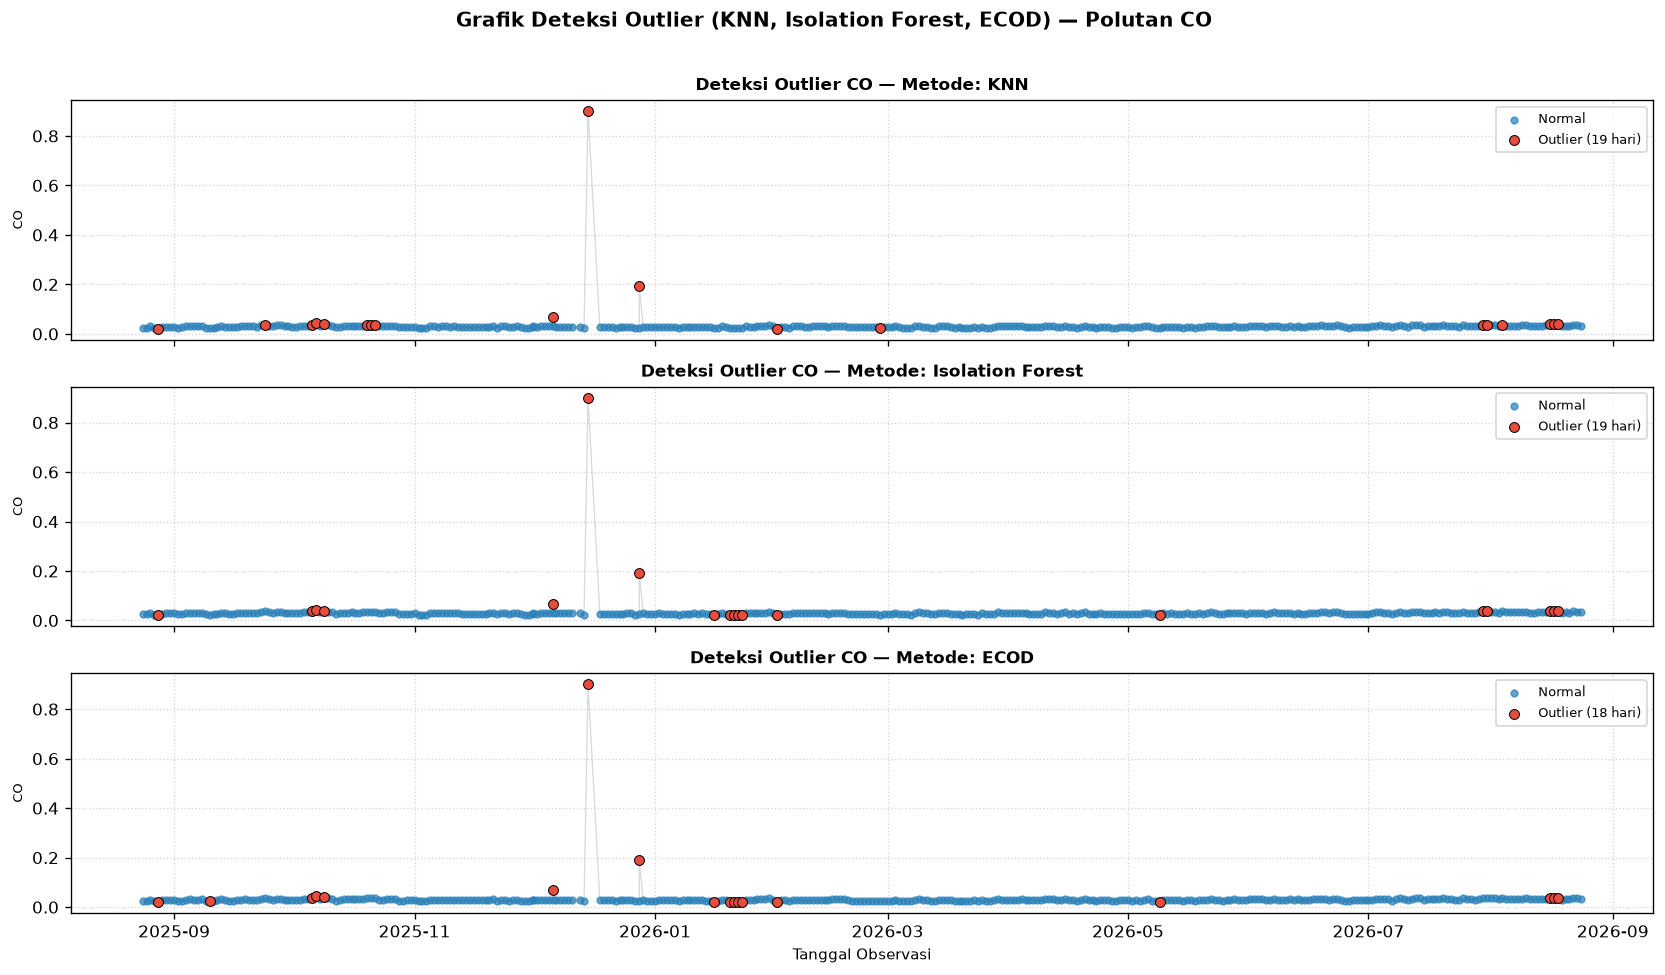

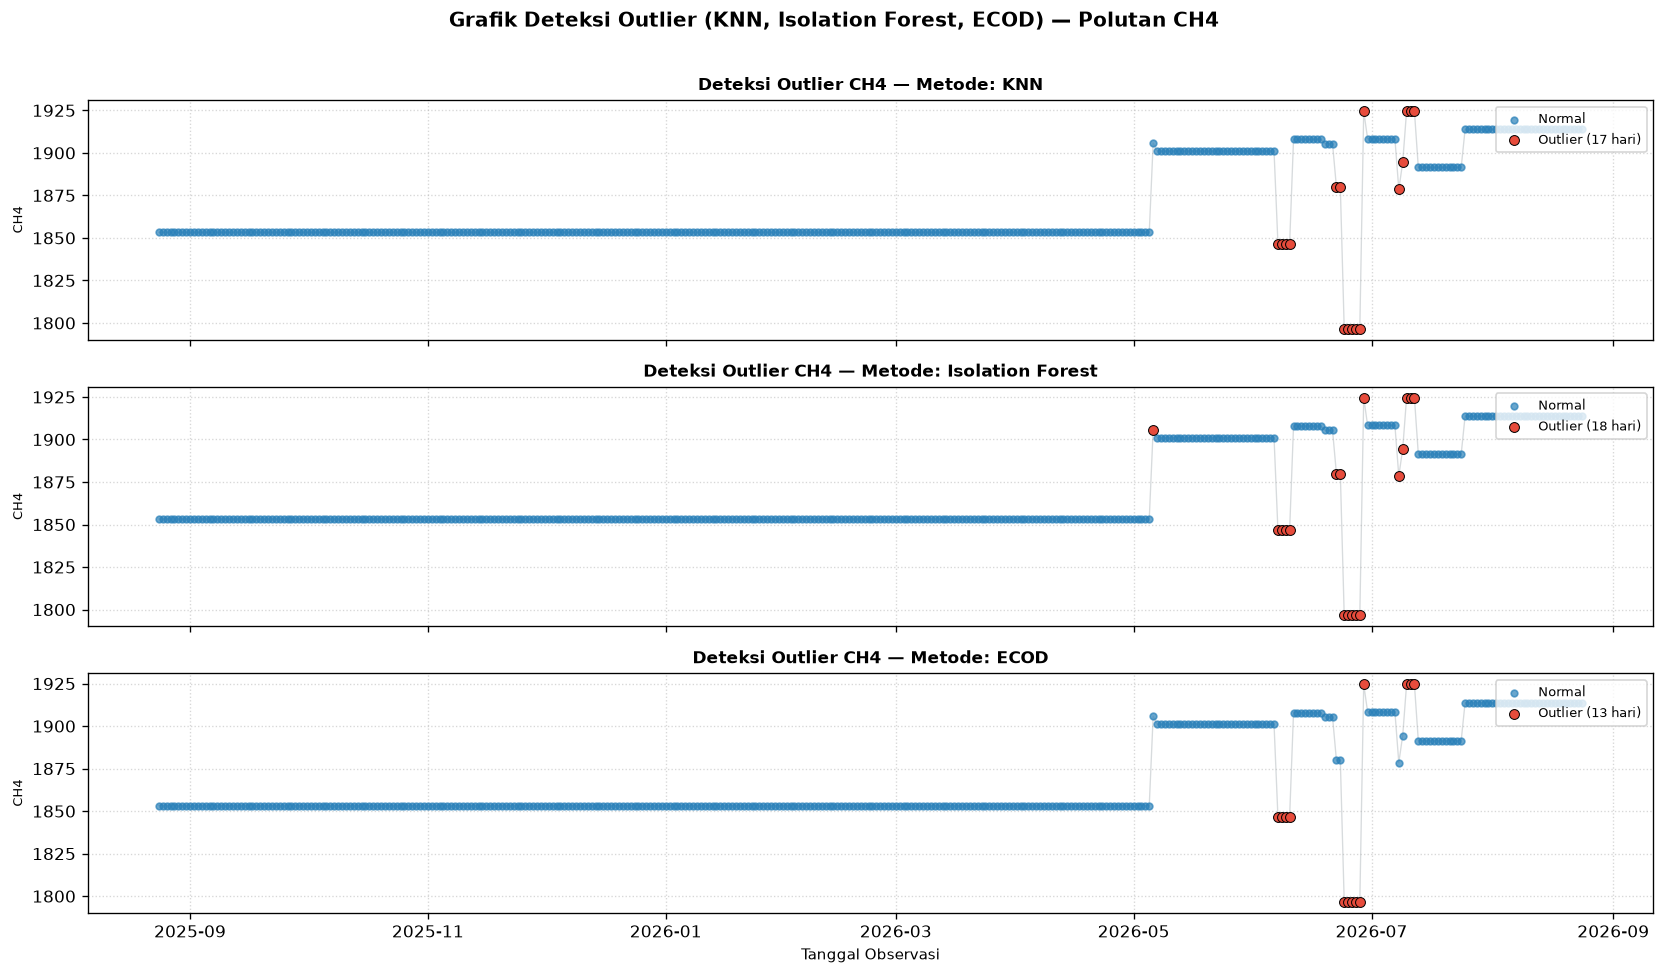

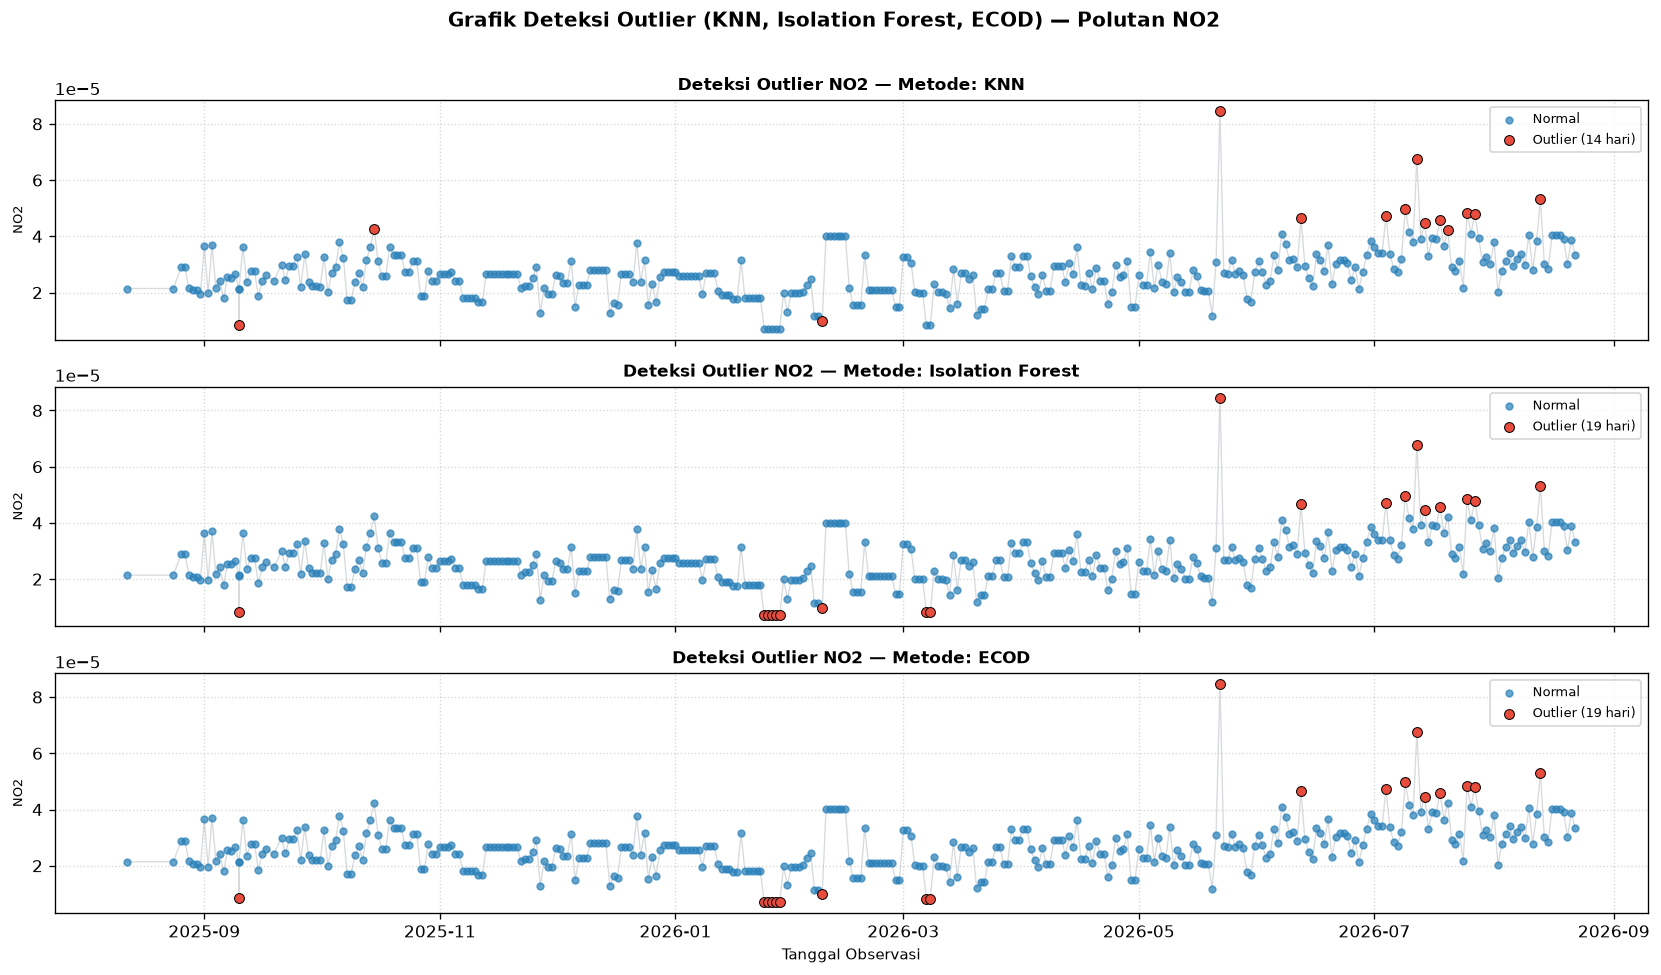

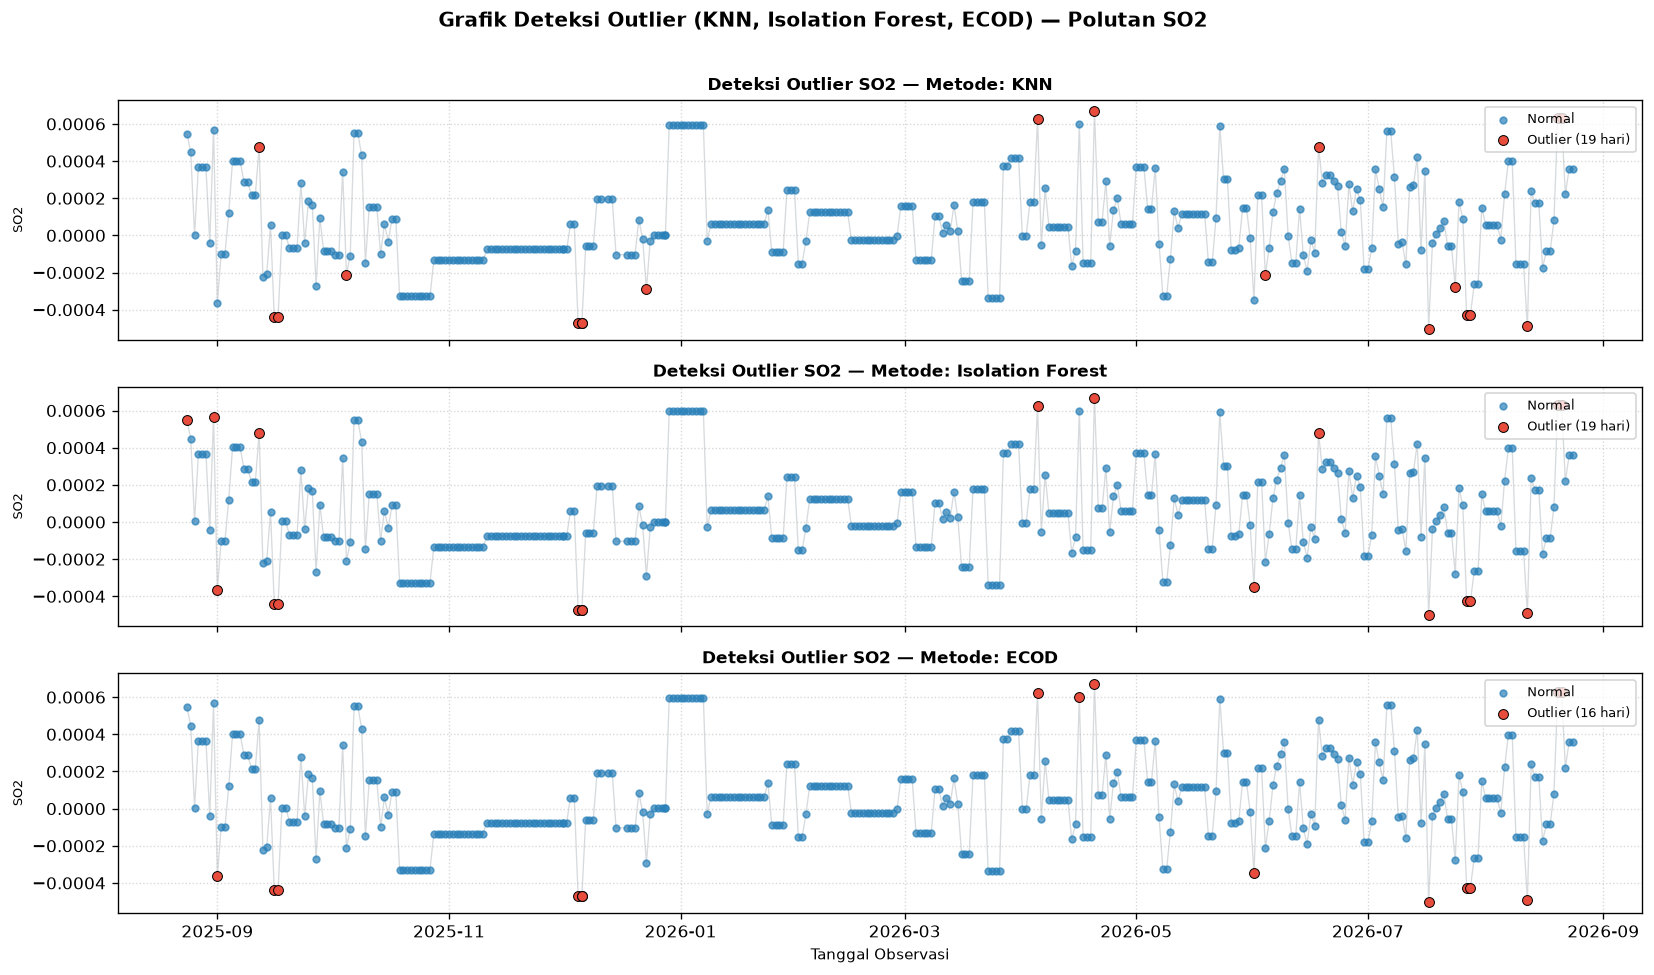

In [5]:
# Visualisasi Subplot 3 Metode Outlier untuk Setiap Polutan
for polutan, df in dfs_imputed.items():
    df_valid = df.dropna(subset=[polutan]).copy()
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_valid[[polutan]].values)
    
    models = {
        'KNN': KNN(contamination=0.05, n_neighbors=5),
        'Isolation Forest': IForest(contamination=0.05, random_state=42),
        'ECOD': ECOD(contamination=0.05)
    }
    
    fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True, dpi=120)
    
    for i, (name, model) in enumerate(models.items()):
        model.fit(X_scaled)
        labels = model.labels_
        normal_m = df_valid[labels == 0]
        outliers_m = df_valid[labels == 1]
        
        ax = axes[i]
        ax.plot(df_valid['date'], df_valid[polutan], color='#bdc3c7', linewidth=0.8, alpha=0.6, zorder=1)
        ax.scatter(normal_m['date'], normal_m[polutan], color='#2980b9', s=16, alpha=0.7, label='Normal', zorder=2)
        ax.scatter(outliers_m['date'], outliers_m[polutan], color='#e74c3c', s=35, edgecolors='black', linewidths=0.6, 
                   label=f'Outlier ({len(outliers_m)} hari)', zorder=3)
        
        ax.set_title(f'Deteksi Outlier {polutan} — Metode: {name}', fontsize=10, fontweight='bold')
        ax.set_ylabel(polutan, fontsize=8)
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(True, linestyle=':', alpha=0.5)
        
    plt.xlabel('Tanggal Observasi', fontsize=9)
    plt.suptitle(f'Grafik Deteksi Outlier (KNN, Isolation Forest, ECOD) — Polutan {polutan}', fontsize=12, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

---

## 3. Preprocessing: Penanganan Outlier & Pembersihan Data

Setelah nilai *outlier* terdeteksi, data pencilan tersebut ditandai (*set as NaN*). Selanjutnya, diterapkan kembali teknik **Linear Interpolation** serta *forward/backward fill* untuk menghasilkan deret waktu yang kontinu, halus, dan representatif.

In [6]:
dfs_fixed = {}

for polutan, df in dfs_imputed.items():
    df_fixed = df.copy()
    
    q1 = df_fixed[polutan].quantile(0.25)
    q3 = df_fixed[polutan].quantile(0.75)
    iqr = q3 - q1
    batas_bawah = q1 - 1.5 * iqr
    batas_atas = q3 + 1.5 * iqr
    
    outliers = (df_fixed[polutan] < batas_bawah) | (df_fixed[polutan] > batas_atas)
    
    # Ubah outlier menjadi None/NaN
    df_fixed.loc[outliers, polutan] = None
    
    # Interpolasi linier untuk mengisi outlier
    df_fixed[polutan] = df_fixed[polutan].interpolate(method='linear').ffill().bfill()
    
    # Simpan dataset bersih
    save_path = f"data/{polutan}_lamongan_fix.csv"
    df_fixed.to_csv(save_path, index=False)
    dfs_fixed[polutan] = df_fixed
    print(f"Data bersih {polutan:4s} berhasil disimpan ke: {save_path}")

Data bersih CO   berhasil disimpan ke: data/CO_lamongan_fix.csv
Data bersih CH4  berhasil disimpan ke: data/CH4_lamongan_fix.csv
Data bersih NO2  berhasil disimpan ke: data/NO2_lamongan_fix.csv
Data bersih SO2  berhasil disimpan ke: data/SO2_lamongan_fix.csv


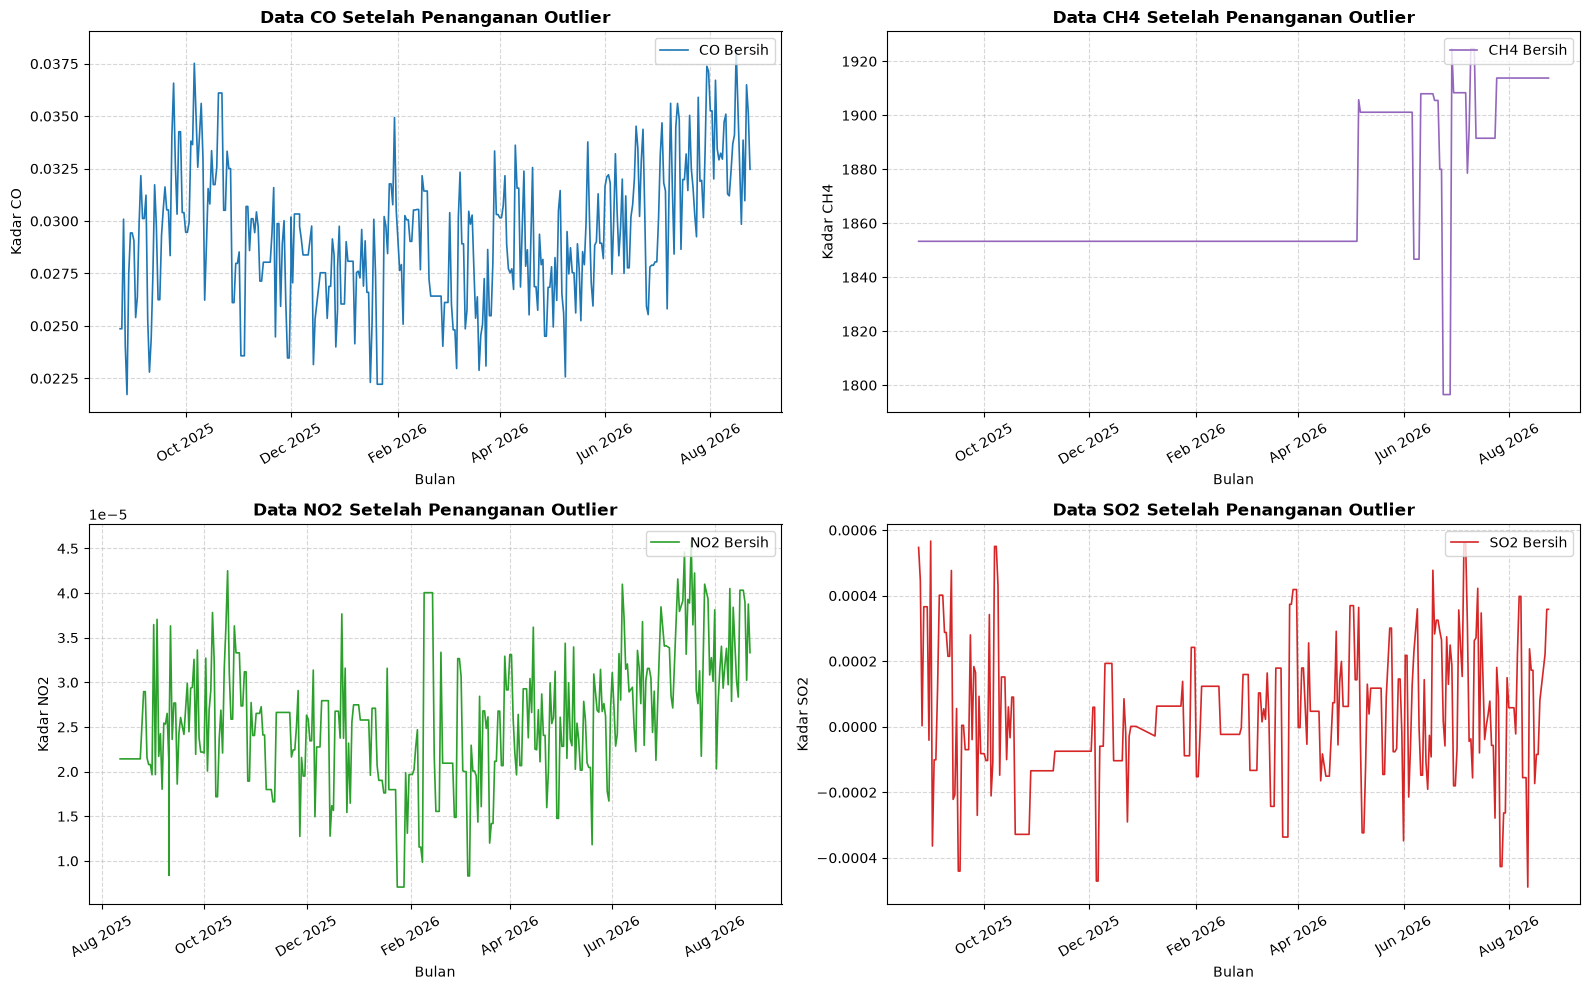

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

colors = ['#1f77b4', '#9467bd', '#2ca02c', '#d62728']

for idx, (polutan, df) in enumerate(dfs_fixed.items()):
    ax = axes[idx]
    
    ax.plot(df['date'], df[polutan], linewidth=1.2, color=colors[idx], label=f'{polutan} Bersih')
    ax.set_title(f'Data {polutan} Setelah Penanganan Outlier', fontsize=12, fontweight='bold')
    ax.set_xlabel('Bulan', fontsize=10)
    ax.set_ylabel(f'Kadar {polutan}', fontsize=10)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.tick_params(axis='x', rotation=30)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

---

## 4. Ekstraksi Fitur Time Series (68 Fitur TSFEL)

Setelah rangkaian data polutan bersih dari *missing value* dan *outlier*, dilakukan ekstraksi fitur numerik menggunakan library **TSFEL (*Time Series Feature Extraction Library*)**. 

Fitur yang diekstraksi sebanyak **68 fitur** yang mencakup:
- **Domain Statistical (17 Fitur):** `calc_max`, `calc_min`, `calc_mean`, `calc_median`, `calc_std`, `calc_var`, `ecdf`, `ecdf_percentile`, `ecdf_percentile_count`, `ecdf_slope`, `hist_mode`, `interq_range`, `kurtosis`, `skewness`, `mean_abs_deviation`, `median_abs_deviation`, `rms`.
- **Domain Temporal (25 Fitur):** `abs_energy`, `auc`, `autocorr`, `average_power`, `calc_centroid`, `dfa`, `distance`, `entropy`, `higuchi_fractal_dimension`, `petrosian_fractal_dimension`, `hurst_exponent`, `lempel_ziv`, `maximum_fractal_length`, `mean_abs_diff`, `mean_diff`, `median_abs_diff`, `median_diff`, `mse`, `negative_turning`, `positive_turning`, `neighbourhood_peaks`, `pk_pk_distance`, `slope`, `sum_abs_diff`, `zero_cross`.
- **Domain Spectral (26 Fitur):** `fundamental_frequency`, `max_frequency`, `median_frequency`, `human_range_energy`, `lpcc`, `mfcc`, `max_power_spectrum`, `power_bandwidth`, `spectral_centroid`, `spectral_decrease`, `spectral_distance`, `spectral_entropy`, `spectral_kurtosis`, `spectral_positive_turning`, `spectral_roll_off`, `spectral_roll_on`, `spectral_skewness`, `spectral_slope`, `spectral_spread`, `spectral_variation`, `spectrogram_mean_coeff`, `wavelet_abs_mean`, `wavelet_energy`, `wavelet_entropy`, `wavelet_std`, `wavelet_var`.

In [8]:
import os
import inspect
import tsfel.feature_extraction.features as tsfel_features

FEATURE_LIST = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()

print(f"Total daftar fitur TSFEL yang diekstrak: {len(FEATURE_LIST)} fitur\n")

def to_scalar(result):
    if isinstance(result, dict) and "values" in result:
        result = result["values"]
    if isinstance(result, (list, tuple, np.ndarray)):
        arr = np.asarray(result, dtype=float)
        return float(np.nanmean(arr))
    return float(result)

def extract_one(fn_name, signal, fs=1):
    fn = getattr(tsfel_features, fn_name)
    params = inspect.signature(fn).parameters
    if "fs" in params:
        result = fn(signal, fs)
    else:
        result = fn(signal)
    return to_scalar(result)

os.makedirs("data/polutan", exist_ok=True)
tsfel_results = {}

for polutan, df in dfs_fixed.items():
    signal_1d = df[polutan].astype(float).values
    row = {}
    
    for i, fn_name in enumerate(FEATURE_LIST, start=1):
        col_name = f"f{i}_{fn_name}"
        row[col_name] = extract_one(fn_name, signal_1d, fs=1)
        
    df_features = pd.DataFrame([row])
    
    # Simpan ke folder data/polutan dan folder data/
    csv_path_polutan = f"data/polutan/{polutan}_Lamongan_TSFEL.csv"
    csv_path_data = f"data/{polutan}_Lamongan_TSFEL.csv"
    
    df_features.to_csv(csv_path_polutan, index=False)
    try:
        df_features.to_csv(csv_path_data, index=False)
    except Exception:
        pass
        
    tsfel_results[polutan] = df_features
    
    print(f"✓ Berhasil mengekstrak {df_features.shape[1]} fitur untuk polutan {polutan:4s} -> Disimpan di {csv_path_polutan}")

Total daftar fitur TSFEL yang diekstrak: 68 fitur



C:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\tsfel\feature_extraction\features_utils.py:534: RuntimeWarning: invalid value encountered in divide
  rs = np.divide(r, s)


✓ Berhasil mengekstrak 68 fitur untuk polutan CO   -> Disimpan di data/polutan/CO_Lamongan_TSFEL.csv


C:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\tsfel\feature_extraction\features_utils.py:534: RuntimeWarning: invalid value encountered in divide
  rs = np.divide(r, s)
C:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\tsfel\feature_extraction\features_utils.py:534: RuntimeWarning: invalid value encountered in divide
  rs = np.divide(r, s)


✓ Berhasil mengekstrak 68 fitur untuk polutan CH4  -> Disimpan di data/polutan/CH4_Lamongan_TSFEL.csv


✓ Berhasil mengekstrak 68 fitur untuk polutan NO2  -> Disimpan di data/polutan/NO2_Lamongan_TSFEL.csv


✓ Berhasil mengekstrak 68 fitur untuk polutan SO2  -> Disimpan di data/polutan/SO2_Lamongan_TSFEL.csv


C:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\tsfel\feature_extraction\features_utils.py:534: RuntimeWarning: invalid value encountered in divide
  rs = np.divide(r, s)


In [9]:
from IPython.display import display, HTML

# --- Tabel Gabungan Semua Polutan (baris = polutan, kolom = fitur) ---
print("=" * 70)
print("TABEL PERBANDINGAN FITUR TSFEL - SEMUA POLUTAN (68 Fitur)")
print("=" * 70)

combined_list = []
for polutan, df_feat in tsfel_results.items():
    row = df_feat.copy()
    row.insert(0, "Polutan", polutan)
    combined_list.append(row)

df_combined = pd.concat(combined_list, ignore_index=True)
df_combined = df_combined.set_index("Polutan")

display(df_combined.style
    .format("{:.6g}")
    .set_caption("Hasil Ekstraksi 68 Fitur TSFEL untuk Semua Polutan")
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold'), ('text-align', 'left'), ('padding-bottom', '8px')]},
        {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('font-size', '11px'), ('text-align', 'center'), ('padding', '4px 6px')]},
        {'selector': 'td', 'props': [('font-size', '11px'), ('text-align', 'right'), ('padding', '4px 6px')]},
        {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#f2f2f2')]},
    ])
)

TABEL PERBANDINGAN FITUR TSFEL - SEMUA POLUTAN (68 Fitur)


,f1_abs_energy,f2_auc,f3_autocorr,f4_average_power,f5_calc_centroid,f6_calc_max,f7_calc_mean,f8_calc_median,f9_calc_min,f10_calc_std,f11_calc_var,f12_dfa,f13_distance,f14_ecdf,f15_ecdf_percentile,f16_ecdf_percentile_count,f17_ecdf_slope,f18_entropy,f19_fundamental_frequency,f20_higuchi_fractal_dimension,f21_hist_mode,f22_human_range_energy,f23_hurst_exponent,f24_interq_range,f25_kurtosis,f26_lempel_ziv,f27_lpcc,f28_max_frequency,f29_max_power_spectrum,f30_maximum_fractal_length,f31_mean_abs_deviation,f32_mean_abs_diff,f33_mean_diff,f34_median_abs_deviation,f35_median_abs_diff,f36_median_diff,f37_median_frequency,f38_mfcc,f39_mse,f40_negative_turning,f41_neighbourhood_peaks,f42_petrosian_fractal_dimension,f43_pk_pk_distance,f44_positive_turning,f45_power_bandwidth,f46_rms,f47_skewness,f48_slope,f49_spectral_centroid,f50_spectral_decrease,f51_spectral_distance,f52_spectral_entropy,f53_spectral_kurtosis,f54_spectral_positive_turning,f55_spectral_roll_off,f56_spectral_roll_on,f57_spectral_skewness,f58_spectral_slope,f59_spectral_spread,f60_spectral_variation,f61_spectrogram_mean_coeff,f62_sum_abs_diff,f63_wavelet_abs_mean,f64_wavelet_energy,f65_wavelet_entropy,f66_wavelet_std,f67_wavelet_var,f68_zero_cross
Polutan,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
CO,0.318632,10.7045,7,0.000872964,188.13,0.0382186,0.0293257,0.0293447,0.021727,0.00325329,1.05839e-05,0.856872,365.001,0.0150273,0.0291997,182.5,117.112,0.94384,0.00273224,1.89507,0.0307974,0,0.758232,0.00438857,-0.254132,0.188525,0.901315,0.401639,38.0871,-0.0663158,0.00261603,0.0020348,2.08313e-05,0.00220894,0.00178125,0,0,18.3549,1.17419,68,16,1.04219,0.0164916,76,0.412568,0.0295056,0.148718,7.31794e-06,0.0818479,-7.40048,-1180.58,0.738229,4.37686,57,0.401639,0,1.59719,-0.0433915,0.133973,0.49846,1.4068e-05,0.742701,0.00177561,0.00746624,2.13325,0.00722947,6.05471e-05,0
CH4,1.27594e+09,681423,31,3.49572e+06,184.441,1924.69,1866.96,1853.3,1796.53,25.2344,636.773,1.0571,911.511,0.0150273,1877.21,182.5,0.00654717,0.208194,0.00273224,1.54052,1854.2,0,0.899558,38.1844,-0.114034,0.10929,0.978051,0.0163934,70.2275,2.93245,21.3931,1.5343,0.165717,0,0,0,0,-0.599346,0.149175,1,2,1.00422,128.16,2,0.106557,1867.13,0.73337,0.160877,0.00867326,-83.0171,-6.49198e+07,0.531724,56.3059,33,0.0163934,0,7.02803,-0.0622742,0.0485282,0.355645,573.333,560.02,109.742,403.324,1.95428,387.409,188085,0
NO2,2.65706e-07,0.00942996,3,7.31973e-10,201.216,4.58185e-05,2.59817e-05,2.63704e-05,7.07172e-06,7.41035e-06,5.49133e-11,0.827786,363,0.0151099,2.58844e-05,181.5,55572.6,0.918763,0.00274725,1.91238,2.83824e-05,0,0.677004,9.90685e-06,-0.0403588,0.200549,0.739025,0.450549,46.3242,-2.69326,5.82583e-06,4.71388e-06,3.27744e-08,5.09012e-06,3.41769e-06,0,0.0686813,34.9894,1.4428,69,13,1.0434,3.87468e-05,73,0.431319,2.70178e-05,0.0277192,2.27049e-08,0.135418,-2.59178,-1.26138,0.800225,2.4348,62,0.450549,0,0.902561,-0.0297277,0.156831,0.401008,7.60353e-11,0.00171114,1.73579e-06,1.12087e-05,2.16019,1.10497e-05,1.31936e-10,0
SO2,1.54544e-05,0.0501338,2,4.23408e-08,178.553,0.000566353,2.90595e-05,1.16358e-06,-0.000489161,0.000203422,4.13807e-08,0.951589,365,0.0150273,2.30261e-05,182.5,1659.82,0.815274,0.00273224,1.90178,-0.000119731,0,0.602149,0.000240332,0.109528,0.191257,0.156397,0.461749,11.006,-1.24323,0.000160449,0.000109997,-5.17485e-07,0.000122342,2.6799e-06,0,0.15847,29.765,1.17224,34,3,1.03351,0.00105551,32,0.377049,0.000205488,0.162898,2.63222e-07,0.189767,-0.0395463,-13.5301,0.866994,2.02126,62,0.461749,0.00546448,0.504212,-0.0155432,0.145932,0.169404,6.50207e-08,0.0401488,7.24998e-06,0.000277231,2.17791,0.000277126,7.89129e-08,88


---

# Penjelasan Domain Fitur TSFEL

TSFEL (_Time Series Feature Extraction Library_) menyediakan berbagai fitur yang dapat digunakan untuk menggambarkan karakteristik suatu data deret waktu. Fitur-fitur tersebut dapat dikelompokkan berdasarkan sudut pandang analisisnya, yaitu **Statistical**, **Temporal**, dan **Spectral**.

Pembagian ini memungkinkan data deret waktu polutan dianalisis secara lebih menyeluruh. Domain statistik berfokus pada karakteristik nilai dan distribusi data, domain temporal melihat pola perubahan berdasarkan urutan waktu, sedangkan domain spektral mempelajari pola berdasarkan komponen frekuensinya.

## 1. Domain Statistical

Domain **Statistical** digunakan untuk memperoleh informasi mengenai karakteristik numerik dari kumpulan nilai dalam deret waktu. Analisis pada domain ini dapat memberikan gambaran mengenai pusat data, tingkat penyebaran, bentuk distribusi, serta besarnya variasi nilai polutan.

Beberapa fitur statistik yang digunakan antara lain:

- **`calc_max`**: Menghasilkan nilai paling tinggi yang terdapat pada sinyal polutan.
- **`calc_min`**: Menentukan nilai terendah dari keseluruhan data.
- **`calc_mean`**: Menghitung nilai rata-rata dari data polutan.
- **`calc_median`**: Menentukan nilai tengah setelah data diurutkan.
- **`calc_std`**: Mengukur seberapa jauh nilai data tersebar dari nilai rata-ratanya melalui standar deviasi.
- **`calc_var`**: Menunjukkan tingkat variasi data berdasarkan nilai varians.
- **`ecdf`**: Menggambarkan distribusi kumulatif empiris dari nilai-nilai pada deret waktu.
- **`ecdf_percentile`**: Menghasilkan informasi persentil berdasarkan distribusi kumulatif empiris.
- **`ecdf_percentile_count`**: Menghitung jumlah data yang berkaitan dengan posisi persentil tertentu pada ECDF.
- **`ecdf_slope`**: Menggambarkan perubahan atau kemiringan distribusi pada ECDF.
- **`hist_mode`**: Menentukan nilai yang paling sering muncul berdasarkan distribusi histogram.
- **`interq_range`**: Mengukur rentang 50% bagian tengah data menggunakan selisih antara kuartil ketiga dan kuartil pertama.
- **`kurtosis`**: Menggambarkan karakteristik bentuk distribusi, khususnya tingkat keruncingan atau ketebalan ekornya.
- **`skewness`**: Menunjukkan tingkat kemiringan distribusi data terhadap nilai pusatnya.
- **`mean_abs_deviation`**: Menghitung rata-rata jarak absolut setiap nilai terhadap nilai pusat.
- **`median_abs_deviation`**: Mengukur penyebaran data berdasarkan median sehingga relatif lebih tahan terhadap nilai ekstrem.
- **`rms`**: Menghitung _Root Mean Square_, yaitu ukuran besarnya nilai sinyal berdasarkan akar dari rata-rata kuadrat seluruh nilai.

Fitur pada domain statistik dapat digunakan untuk mengetahui bagaimana karakteristik umum dan penyebaran data polutan selama periode pengamatan.

## 2. Domain Temporal

Domain **Temporal** mempertimbangkan susunan nilai berdasarkan waktu. Berbeda dengan statistik yang lebih menitikberatkan pada distribusi nilai, fitur temporal digunakan untuk melihat bagaimana sinyal mengalami perubahan dari satu pengamatan ke pengamatan berikutnya.

Fitur yang termasuk dalam domain ini meliputi:

- **`abs_energy`**: Menghitung akumulasi kuadrat nilai sinyal sehingga dapat digunakan untuk menggambarkan besarnya energi keseluruhan sinyal.
- **`auc`**: Menghitung luas area yang terbentuk di bawah kurva deret waktu.
- **`autocorr`**: Mengukur hubungan antara nilai pada suatu waktu dengan nilai pada waktu sebelumnya.
- **`average_power`**: Menentukan besarnya daya rata-rata yang terdapat pada sinyal.
- **`calc_centroid`**: Menentukan posisi pusat massa atau titik keseimbangan sinyal pada dimensi waktunya.
- **`dfa`**: Menggunakan pendekatan _Detrended Fluctuation Analysis_ untuk mempelajari pola korelasi atau ketergantungan jangka panjang dalam deret waktu.
- **`distance`**: Mengukur panjang lintasan yang terbentuk dari perubahan posisi antar titik data secara berurutan.
- **`entropy`**: Menggambarkan tingkat ketidakpastian atau ketidakteraturan yang terdapat pada sinyal.
- **`higuchi_fractal_dimension`**: Mengestimasi dimensi fraktal menggunakan metode Higuchi untuk menggambarkan kompleksitas sinyal.
- **`petrosian_fractal_dimension`**: Mengukur kompleksitas sinyal berdasarkan perubahan atau jumlah variasi pada deret waktu menggunakan pendekatan Petrosian.
- **`hurst_exponent`**: Memberikan informasi mengenai karakteristik memori jangka panjang pada data dan kecenderungan suatu pola untuk berlanjut.
- **`lempel_ziv`**: Menggambarkan kompleksitas pola dalam sinyal berdasarkan struktur dan kemunculan pola yang dapat ditemukan.
- **`maximum_fractal_length`**: Mengukur panjang fraktal maksimum yang diperoleh dari analisis sinyal pada skala tertentu.
- **`mean_abs_diff`**: Menghitung rata-rata nilai absolut dari perubahan antar pengamatan yang berurutan.
- **`mean_diff`**: Menentukan rata-rata perubahan nilai antara satu titik waktu dengan titik waktu berikutnya.
- **`median_abs_diff`**: Menghasilkan median dari nilai perubahan absolut antar data yang berurutan.
- **`median_diff`**: Menghitung median perubahan nilai pada titik-titik waktu yang berdekatan.
- **`mse`**: Menghitung _Mean Squared Error_, yaitu rata-rata kuadrat kesalahan antara nilai sinyal dengan nilai pembanding atau estimasinya.
- **`negative_turning`**: Mengidentifikasi perubahan arah sinyal yang menunjukkan pergerakan dari kondisi meningkat menuju menurun.
- **`positive_turning`**: Mengidentifikasi perubahan arah sinyal dari kondisi menurun menuju meningkat.
- **`neighbourhood_peaks`**: Mendeteksi keberadaan titik puncak dengan mempertimbangkan nilai-nilai di sekitar titik tersebut.
- **`pk_pk_distance`**: Mengukur selisih antara nilai puncak tertinggi dan lembah terendah pada sinyal.
- **`slope`**: Menunjukkan kecenderungan arah perubahan sinyal secara keseluruhan melalui kemiringan garis regresi.
- **`sum_abs_diff`**: Menjumlahkan seluruh perubahan absolut yang terjadi antar titik data secara berurutan.
- **`zero_cross`**: Menghitung jumlah kejadian ketika sinyal melewati atau memotong nilai nol sebagai titik referensi.

Fitur temporal sangat berguna dalam penelitian polutan karena nilai suatu polutan tidak hanya penting dari sisi besarannya, tetapi juga bagaimana nilai tersebut berubah dari hari ke hari.

## 3. Domain Spectral

Domain **Spectral** menganalisis sinyal berdasarkan komponen frekuensi yang terkandung di dalamnya. Pendekatan ini berguna untuk menemukan pola berulang, dominasi frekuensi tertentu, distribusi energi, serta karakteristik perubahan sinyal yang tidak selalu terlihat apabila hanya diamati berdasarkan nilai waktunya.

Fitur-fitur yang digunakan dalam domain ini antara lain:

- **`fundamental_frequency`**: Menentukan frekuensi dasar yang menjadi komponen utama dalam sinyal.
- **`max_frequency`**: Menunjukkan frekuensi tertinggi yang teridentifikasi dalam hasil analisis spektrum.
- **`median_frequency`**: Menentukan titik frekuensi yang membagi distribusi energi spektrum menjadi dua bagian yang relatif seimbang.
- **`human_range_energy`**: Mengukur energi sinyal pada rentang frekuensi tertentu yang didefinisikan dalam TSFEL.
- **`lpcc`**: Menghasilkan _Linear Prediction Cepstral Coefficients_, yaitu representasi karakteristik spektral yang berasal dari pendekatan prediksi linear.
- **`mfcc`**: Menghasilkan _Mel-Frequency Cepstral Coefficients_ untuk merepresentasikan karakteristik spektrum menggunakan skala Mel.
- **`max_power_spectrum`**: Menentukan nilai daya terbesar yang muncul pada spektrum frekuensi.
- **`power_bandwidth`**: Menggambarkan lebar rentang frekuensi yang mengandung sebagian besar energi sinyal.
- **`spectral_centroid`**: Menentukan titik pusat distribusi energi pada spektrum frekuensi.
- **`spectral_decrease`**: Mengukur kecenderungan penurunan magnitudo spektrum ketika frekuensi meningkat.
- **`spectral_distance`**: Mengukur perbedaan antara karakteristik spektrum pada bagian-bagian yang dianalisis.
- **`spectral_entropy`**: Menilai tingkat penyebaran atau ketidakaturan distribusi energi pada spektrum.
- **`spectral_kurtosis`**: Menggambarkan bentuk distribusi spektrum berdasarkan karakteristik keruncingannya.
- **`spectral_positive_turning`**: Mengidentifikasi perubahan arah positif pada karakteristik spektral.
- **`spectral_roll_off`**: Menentukan frekuensi batas ketika sebagian besar energi spektrum telah tercapai.
- **`spectral_roll_on`**: Menentukan posisi awal frekuensi ketika energi spektrum mulai mencapai bagian tertentu dari total energinya.
- **`spectral_skewness`**: Menggambarkan tingkat kemiringan distribusi energi pada spektrum frekuensi.
- **`spectral_slope`**: Mengukur kecenderungan naik atau turunnya magnitudo spektrum terhadap perubahan frekuensi.
- **`spectral_spread`**: Menunjukkan tingkat penyebaran energi frekuensi terhadap posisi _spectral centroid_.
- **`spectral_variation`**: Menggambarkan perubahan karakteristik spektrum dari satu bagian analisis ke bagian lainnya.
- **`spectrogram_mean_coeff`**: Menghasilkan nilai rata-rata koefisien yang diperoleh dari representasi spektrogram.
- **`wavelet_abs_mean`**: Menghitung rata-rata nilai absolut dari koefisien yang diperoleh melalui analisis wavelet.
- **`wavelet_energy`**: Mengukur energi yang terdapat pada koefisien wavelet.
- **`wavelet_entropy`**: Menggambarkan tingkat ketidakaturan distribusi energi pada koefisien wavelet.
- **`wavelet_std`**: Menghitung standar deviasi dari koefisien wavelet.
- **`wavelet_var`**: Menghitung varians dari koefisien wavelet.

Analisis spektral dapat membantu mengidentifikasi pola periodik pada data polutan. Informasi tersebut dapat melengkapi hasil analisis statistik dan temporal sehingga karakteristik deret waktu dapat dipahami dari beberapa sisi.

---

# Evaluasi Perbandingan Clustering K-Means dan Deteksi Outlier

Setelah diperoleh 272 fitur hasil ekstraksi TSFEL dari 19 sampel yang berasal dari masing-masing daerah atau mahasiswa, tahap selanjutnya adalah melakukan proses pengelompokan data menggunakan algoritma **K-Means**. Evaluasi clustering dilakukan dengan membandingkan dua skenario jumlah cluster, yaitu pengelompokan menjadi **2 cluster** dan pengelompokan menjadi **3 cluster / 5 cluster**. Proses clustering dilakukan menggunakan dua pendekatan, yaitu data yang telah direduksi dimensinya menggunakan **PCA** dengan 19 komponen utama (PCA 0 hingga PCA 18) serta data yang tetap menggunakan keseluruhan fitur tanpa reduksi PCA. Perbandingan kedua pendekatan tersebut digunakan untuk melihat perbedaan hasil pengelompokan berdasarkan fitur yang telah direduksi dan fitur TSFEL secara keseluruhan.

## Visualisasi Workflow KNIME & Scatter Plot Analytics Platform

Proses ekstraksi, praprocessing, reduksi dimensi PCA, dan pengelompokan K-Means dijalankan menggunakan alur kerja (*workflow*) KNIME Analytics Platform:
 
```{image} ../img/clustering.png
:alt: Workflow Clustering KNIME
:width: 100%
:align: center
```

Hasil proses clustering yang diperoleh melalui alur KNIME kemudian divisualisasikan menggunakan **Scatter Plot**. Grafik tersebut digunakan untuk memperlihatkan posisi dan persebaran 19 sampel mahasiswa/daerah berdasarkan cluster yang terbentuk. Setiap titik pada grafik merepresentasikan satu sampel, sedangkan label atau warna yang berbeda menunjukkan kelompok (*cluster*) tempat sampel tersebut berada. Visualisasi ini membantu melihat pola pemisahan dan kedekatan antaranggota cluster secara lebih jelas.

### Skenario 1: K-Means (k=2) dengan Reduksi Dimensi PCA

```{image} ../img/k2 pca.png
:alt: K-Means k=2 PCA
:width: 100%
:align: center
```

Berdasarkan hasil clustering menggunakan K-Means dengan reduksi dimensi PCA, data 19 mahasiswa/daerah terbagi menjadi dua kelompok. Sebanyak **18 sampel** berada pada `cluster_0`, sedangkan **1 sampel**, yaitu asal Burneh Bangkalan, berada pada `cluster_1`. Pemisahan satu sampel tersebut menunjukkan bahwa karakteristik fitur yang dimilikinya memiliki perbedaan yang cukup jauh dibandingkan dengan sampel lainnya sehingga membentuk kelompok tersendiri pada hasil clustering.

### Skenario 2: K-Means (k=2) Tanpa Reduksi PCA (272 Fitur Penuh)

```{image} ../img/k2 no pca.png
:alt: K-Means k=2 No PCA
:width: 100%
:align: center
```

Pada pengelompokan menggunakan **K-Means dengan seluruh 272 fitur TSFEL yang telah dinormalisasi tanpa melalui reduksi PCA**, diperoleh pembagian cluster yang sama dengan skenario sebelumnya. Sebanyak **18 daerah** masuk ke dalam **`cluster_0`**, sementara **Burneh, Bangkalan** berada sendiri pada **`cluster_1`**. Hasil ini menunjukkan bahwa daerah tersebut tetap memiliki pola karakteristik yang berbeda dibandingkan 18 daerah lainnya, meskipun proses clustering dilakukan menggunakan seluruh fitur TSFEL tanpa reduksi dimensi.

### Skenario 3: K-Means (k=5) dengan Reduksi Dimensi PCA

```{image} ../img/k5 pca.png
:alt: K-Means k=5 PCA
:width: 100%
:align: center
```

Pada skenario dengan jumlah cluster yang lebih banyak dan menggunakan reduksi dimensi **PCA**, hasil pengelompokan menjadi lebih terperinci. Dari 19 mahasiswa/daerah yang dianalisis, terbentuk **5 kelompok** dengan karakteristik yang berbeda. Sebagian besar sampel, yaitu **14 daerah**, terkumpul pada **`cluster_2`**. Sementara itu, empat daerah lainnya membentuk cluster secara terpisah, yaitu **Kraton, Bangkalan** pada **`cluster_4`**, **Kadur, Pamekasan** pada **`cluster_0`**, **Burneh, Bangkalan** pada **`cluster_1`**, serta **Sokobanah** pada **`cluster_3`**. Hasil tersebut menunjukkan bahwa peningkatan jumlah cluster menghasilkan pembagian kelompok yang lebih spesifik dibandingkan skenario dengan jumlah cluster yang lebih sedikit.

### Skenario 4: K-Means (k=5) Tanpa Reduksi PCA (272 Fitur Penuh)

```{image} ../img/k5 no pca.png
:alt: K-Means k=5 No PCA
:width: 100%
:align: center
```

Pada skenario clustering menggunakan **272 fitur TSFEL secara keseluruhan tanpa menerapkan reduksi dimensi PCA**, diperoleh pola pengelompokan yang relatif sama dengan hasil pada skenario menggunakan PCA. Dari 19 daerah, sebagian besar data tergabung dalam **satu cluster utama**, sedangkan empat daerah lainnya masing-masing membentuk **cluster tersendiri**. Dengan demikian, penggunaan seluruh fitur TSFEL tetap menghasilkan pemisahan terhadap beberapa daerah yang memiliki karakteristik berbeda dari kelompok utama.